# Mapping the supply & demand of public EV charging station distribution across Israel

### Brief intro on charging stations and the Israeli EV market

Electric Vehicles (EVs) play a vital role in the global fight against climate change - transitioning a country's fleet to electric power can significantly slash air pollution and carbon emissions.

A study conducted for the Ministry of Energy mapped the positions of the Israeli consumer regarding the obstacles of electric vehicle usage on the one hand, and the motivations for adoption on the other. Given that there is a supply of vehicles on the market, the study shows that the main barrier, as perceived by consumers, is the lack of public charging stations for electric vehicles in the country.

To overcome the above obstacles, many countries, including Israel, are encouraging the construction of a network of **public** charging stations. These charging stations are intended to allow people who have no **private** charging station to charge their electric vehicle, and thus increase the daily autonomy of the vehicle also for those who have a private charging station. This network consists of fast charging stations that provide direct current (DC) and slow charging stations that provide alternating current (AC).

In general - 'slow' charging stations (AC) are the standard. They're cheaper to build and use - but they require you to charge your car for 6~12 hours for a full charge. They're perfect for overnight charging if you have your own parking spot at home, or for parking during work hours while you're working at the office.
Fast chargers (DC) can top up your battery by 20~60 minutes! But.. fast chargers shorten the EV's battery lifespan. They're also really expensive to build and use.

Most EV owners will ideally want their own parking space with a **private** AC charging station built on it. But what if I don't have my own parking space and I rely on public or curbside parking? That's when the need for a network of **public** charging stations comes in. 

Main question - **Where do we need more public charging stations built?**

In this project I'd like to visualize and quantify in which geographical areas are Israeli citizens lacking public EV charging stations, which in turn might also discourage non-EV owners from switching over to EVs.

### Data sources used in this project

- OpenStreetMap (filtered via Overpass Turbo (https://overpass-turbo.eu/)) databases, for open-source information on Points of Interest (POIs) and parking lot areas.
- Official government data from data.gov, specifically data on existing charging stations from the Ministry of Transport (https://data.gov.il/he/datasets/ministry_of_transport/agg_charge_stations) and the latest census data from the Israel Central Bureau of Statistics (https://data.gov.il/he/datasets/lamas/2022)
- The open-source "Open Bus Stride API" (https://open-bus-stride-api.hasadna.org.il/docs) to get data on Public Transport accesibility in Israel.

### Part 1: Extraction and Exploration of Points of Interest (POIs)

I'll start by using Overpass Turbo queries to get all POIs on OpenstreetMap that are marked as:

<details>
<summary> 'parking', 'parking_space' or 'parking_entrance' (here I included the actual polygons) </summary>

```
{{geocodeArea:Israel}}->.searchArea;

(
  // 1. General parking facilities (surface, multi-storey, underground)
  nwr["amenity"="parking"](area.searchArea);
  
  // 2. Individual parking spaces (useful for density analysis)
  nwr["amenity"="parking_space"](area.searchArea);
  
  // 3. Entrances/Exits to underground or multi-storey parking
  node["amenity"="parking_entrance"](area.searchArea);
);

// Output the results with geometries
out body;
>;
out skel qt;
```

<details>
<summary>'shop', 'restaurant', 'cafe', 'fast_food', 'bank', 'pharmacy', 'clinic', 'hospital', 'office' (here I only pulled the centroids, since I'm planning on clustering them) </summary>

```
[out:json][timeout:300];

{{geocodeArea:Israel}}->.searchArea;

(
  // 2. Commercial: All shops (malls, supermarkets, boutiques)
  nwr["shop"](area.searchArea);
  
  // 3. Amenities: Restaurants, cafes, banks, pharmacies, clinics
  nwr["amenity"~"restaurant|cafe|fast_food|bank|pharmacy|clinic|hospital"](area.searchArea);
  
  // 4. Offices: Corporate buildings, co-working spaces
  nwr["office"](area.searchArea);
  
);

/* Used 'out center' so I only get the centroids of my POIs
*/
out center;
```

In [185]:
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt
from sklearn.cluster import OPTICS
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors
from plotly.subplots import make_subplots
from sklearn.neighbors import BallTree
from scipy.stats import norm

file_path = "POIs_center.geojson"
poi_df = gpd.read_file(file_path)

Skipping field service_times: unsupported OGR type: 10


In [186]:
pd.set_option('display.max_rows', 200)

In [187]:
poi_df.info()
print('\n', poi_df.head(), '\n')

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33774 entries, 0 to 33773
Columns: 631 entries, id to geometry
dtypes: datetime64[ms](7), float64(1), geometry(1), str(622)
memory usage: 162.6 MB

                  id               @id FIXME Rate access addr:city  \
0     way/239196738     way/239196738   NaN  NaN    NaN       NaN   
1     way/639130875     way/639130875   NaN  NaN    NaN       NaN   
2  relation/2674121  relation/2674121   NaN  NaN    NaN       NaN   
3  relation/2720477  relation/2720477   NaN  NaN    NaN       NaN   
4  relation/3231325  relation/3231325   NaN  NaN    NaN       NaN   

  addr:city:ar addr:city:arc addr:city:en addr:city:he  ... wikidata  \
0          NaN           NaN          NaN          NaN  ...      NaN   
1          NaN           NaN          NaN          NaN  ...      NaN   
2          NaN           NaN          NaN          NaN  ...      NaN   
3          NaN           NaN          NaN          NaN  ...      NaN   
4          NaN    

Right off the bat, we can see a ton of useless columns. Each point on Openpass can have up to 631 possible 'tags', but we only queried for 4 specific tags (amenity, shop, office, leisure) so we can safely remove all of the columns related to tags we did not ask for.

['amenity', 'shop', 'office', 'geometry'] 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33774 entries, 0 to 33773
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   amenity   6396 non-null   str     
 1   shop      9739 non-null   str     
 2   office    859 non-null    str     
 3   geometry  33774 non-null  geometry
dtypes: geometry(1), str(3)
memory usage: 1.0 MB

   amenity         shop office  \
0     NaN  convenience    NaN   
1     NaN          NaN    yes   
2     NaN          NaN    NaN   
3     NaN          NaN    NaN   
4     NaN          NaN    NaN   

                                            geometry  
0  LINESTRING (34.63127 31.76679, 34.63107 31.766...  
1  LINESTRING (34.77307 31.60403, 34.77312 31.604...  
2                           POINT (34.63878 31.7865)  
3                          POINT (34.77786 31.89644)  
4                          POINT (34.62785 31.77136)  


<Axes: >

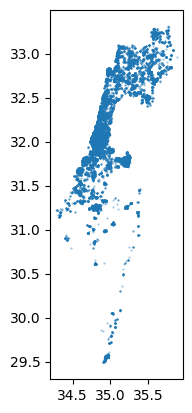

In [188]:
expected_cols = ['amenity', 'shop', 'office', 'geometry']

# check if these columns exists first
existing_cols = [col for col in expected_cols if col in poi_df.columns]
print(existing_cols, '\n') # cool! they're all here and have the expected names

poi_df = poi_df[existing_cols]
poi_df.info()
print('\n', poi_df.head())
poi_df.plot(markersize=0.2, alpha=0.5) 
# the map looks nice! looks like the OSM data is extensive across the country

In [189]:
# I noticed the geometry also includes non-centroids!
print(poi_df.geometry.geom_type.value_counts())

# It's just the first two.. weird! I'll just drop those two rows.
poi_df = poi_df[poi_df.geometry.geom_type == 'Point'].reset_index(drop=True)
# poi_df = poi_df.reset_index(drop=True)
print("\n \n AFTER DROPPING LINESTRINGS")
poi_df.info()
print(poi_df)

Point         33772
LineString        2
Name: count, dtype: int64

 
 AFTER DROPPING LINESTRINGS
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33772 entries, 0 to 33771
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   amenity   6396 non-null   str     
 1   shop      9738 non-null   str     
 2   office    858 non-null    str     
 3   geometry  33772 non-null  geometry
dtypes: geometry(1), str(3)
memory usage: 1.0 MB
          amenity         shop office                   geometry
0             NaN          NaN    NaN   POINT (34.63878 31.7865)
1             NaN          NaN    NaN  POINT (34.77786 31.89644)
2             NaN          NaN    NaN  POINT (34.62785 31.77136)
3             NaN         mall    NaN  POINT (35.54993 32.96903)
4             NaN          NaN    NaN  POINT (35.24244 31.82048)
...           ...          ...    ...                        ...
33767  restaurant          NaN    NaN   POI

In [190]:
print(poi_df[['amenity']].value_counts())

# I notice a lot of tags I didn't ask for. Let's remove them:
queried_amenities = ['restaurant', 'cafe', 'fast_food', 'bank', 'pharmacy', 'clinic', 'hospital']
poi_df.loc[~poi_df['amenity'].isin(queried_amenities), 'amenity'] = np.nan


amenity         
restaurant          2070
fast_food           1420
cafe                1283
clinic               584
bank                 467
pharmacy             411
hospital             118
fuel                  11
internet_cafe          9
parking                3
car_rental             3
bicycle_rental         2
ice_cream              2
drinking_water         2
events_venue           1
cafeteria              1
library                1
kindergarten           1
arts_centre            1
service_center         1
veterinary             1
bar                    1
community_centre       1
music_school           1
boat_rental            1
Name: count, dtype: int64


In [191]:
# I should remove any empty rows I created:
categories = ['amenity', 'shop', 'office']
poi_df.dropna(subset=categories, how='all', inplace=True)

print("AFTER FILTERING TAGS")
print(poi_df[['amenity']].value_counts())
poi_df.info()

AFTER FILTERING TAGS
amenity   
restaurant    2070
fast_food     1420
cafe          1283
clinic         584
bank           467
pharmacy       411
hospital       118
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 16921 entries, 3 to 33771
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   amenity   6353 non-null   str     
 1   shop      9738 non-null   str     
 2   office    858 non-null    str     
 3   geometry  16921 non-null  geometry
dtypes: geometry(1), str(3)
memory usage: 661.0 KB


In [192]:
# Now let's look at 'office':
print(poi_df.loc[poi_df['office'].notna(), 'office'].value_counts())

# I don't see a lot of difference between them in terms of parking-needs..
# Since I only care about having an office somewhere - of any type, I'll turn it into a categorical
poi_df['office_cat'] = np.where(poi_df['office'].notna(), 'Office', 'NotOffice')
poi_df['office_cat'] = poi_df['office_cat'].astype('category')

poi_df = poi_df.drop(columns='office')
poi_df


office
government                 201
diplomatic                 112
company                    110
yes                         83
educational_institution     61
estate_agent                51
research                    43
lawyer                      36
insurance                   19
religion                    18
ngo                         17
it                          14
association                 14
coworking                   10
telecommunication            9
employment_agency            9
union                        5
newspaper                    4
water_utility                4
architect                    4
physician                    3
administrative               3
accountant                   3
consulting                   3
foundation                   2
political_party              2
forestry                     1
energy_supplier              1
guide                        1
quango                       1
human_resources              1
security                     1
d

,amenity,shop,geometry,office_cat
3,NaN,mall,POINT (35.54993 32.96903),NotOffice
6,NaN,mall,POINT (34.93367 32.5692),NotOffice
11,hospital,NaN,POINT (35.2186 31.78395),NotOffice
18,hospital,NaN,POINT (35.24952 31.78659),NotOffice
19,NaN,mall,POINT (34.79863 31.24743),NotOffice
...,...,...,...,...
33767,restaurant,NaN,POINT (35.32373 32.9264),NotOffice
33768,NaN,hairdresser,POINT (34.77408 32.08414),NotOffice
33769,cafe,NaN,POINT (34.77457 32.07763),NotOffice
33770,cafe,NaN,POINT (34.77298 32.07768),NotOffice


In [193]:
# Last one - time to look at 'shops'
print(poi_df.loc[poi_df['shop'].notna(), 'shop'].value_counts().head(50))

shop
supermarket      1226
convenience       977
clothes           964
bakery            416
mall              406
hairdresser       340
greengrocer       209
shoes             197
kiosk             189
electronics       187
yes               184
car_repair        183
bicycle           179
books             154
car               152
furniture         147
hardware          145
gift              144
mobile_phone      138
butcher           131
optician          126
jewelry           123
florist           117
toys              111
houseware         107
confectionery     106
beauty            104
pet               101
deli               99
computer           98
alcohol            93
cosmetics          82
stationery         78
sports             76
doityourself       75
laundry            69
variety_store      67
vacant             65
tyres              53
lottery            47
garden_centre      46
wine               42
car_parts          40
chemist            40
outdoor            40
seafo

Unlike offices, I can see some differentiation between shop types here..
For example:
- 'mall' - people spend more time here than other types of shops, even hours.
- 'furniture' - like IKEA and Design Center. People spend time here and ALSO tend to get here via car.
- 'doityourself' refers to places like Ace, HomeDepot - tends to be long stays and car-centric as well.
- 'supermarket' and 'hairdresser' - people can stay here for 30+ minutes at a time.
- 'greengrocer', 'bakery' - daily, high-frequency stops, but with low parking time.
- 'car_repair', 'car', 'tyres', and 'car_parts' have no need for public EV charging stations.
- 'yes' is just bad data. I don't need a categorical here.


In [194]:
drop_shops = ['car_repair', 'car', 'tyres', 'car_parts', 'yes']

# Let's drop the car shops and the 'yes' tag
to_drop = poi_df[poi_df['shop'].isin(drop_shops)].index
poi_df.drop(to_drop, inplace=True)

In [195]:
# lets check for points that belong to more than 1 category
categories = ['shop', 'amenity']
poi_df['cat_count'] = poi_df[categories].notnull().sum(axis=1)

# Let's try to take a look at the rows that have 2 categories:
print(poi_df.loc[poi_df['cat_count'] > 1, categories])

# I see some pairs that repeat themselves.. let's quantify them:
def get_col_combination(row):
    cols_with_data = [row[col] for col in categories if pd.notnull(row[col])]
    return tuple(sorted(cols_with_data))

combination_counts = poi_df[poi_df['cat_count'] > 1].apply(get_col_combination, axis=1).value_counts()
print('\n', combination_counts), combination_counts.info()


               shop     amenity
15766       chemist    pharmacy
18991        bakery        cafe
19671         kiosk   fast_food
19703        bakery        cafe
21637        bakery        cafe
21794        bakery        cafe
21975        bakery        cafe
21988          food  restaurant
22325   supermarket    pharmacy
22895         dairy  restaurant
23166       lottery   fast_food
23492        bakery        cafe
25437  dry_cleaning   fast_food
25754   convenience   fast_food
26787       laundry        cafe
27542          gift        cafe
27743   convenience        cafe
28867        bakery        cafe
29343        sports        cafe
30017        coffee        cafe
30025        coffee        cafe
31167        bakery        cafe
31398        bakery        cafe
32350       chemist    pharmacy
32361       chemist    pharmacy
32416        bakery        cafe
33178       clothes        cafe

 (bakery, cafe)               10
(chemist, pharmacy)           3
(cafe, coffee)                2
(fast_

(None, None)

In [196]:
# At this point I can go over the pairs manually and make a few decisions:
# Chemist+pharmacy is a duplicate. Not all chemists (places like Laline) are pharmacies, but every pharmacy is a chemist.
poi_df.loc[(poi_df['amenity'] == 'pharmacy') & (poi_df['shop'] == 'chemist'), 'shop'] = np.nan

# coffee shops are coffee shops. Even if it's a coffee-gift shop or a coffee-bakery. The secondary tags don't add information.
poi_df.loc[(poi_df['amenity'] == 'cafe'), 'shop'] = np.nan
poi_df.loc[(poi_df['shop'] == 'coffee'), 'shop'] = 'cafe'

# fast food + kiosk/convenience (like 7eleven) is really just a kiosk/convenience (fast_food+dry_cleaning is hilarious.. I'll keep it as dry cleaning)
poi_df.loc[(poi_df['amenity'] == 'fast_food') & (poi_df['shop'].notna()), 'amenity'] = np.nan

# restaurant+food/dairy is redundant, I'll keep the restaurant tag
poi_df.loc[(poi_df['amenity'] == 'restaurant') & (poi_df['shop'].notna()), 'shop'] = np.nan

# supermarket pharmacy is.. SuperPharm/Shufersal. I'll go with supermarket, since people tend to park and stay for awhile here, more than a pharmacy
poi_df.loc[(poi_df['amenity'] == 'pharmacy') & (poi_df['shop'] == 'supermarket'), 'amenity'] = np.nan

# Let's see if we have any more pairs left..
poi_df['cat_count'] = poi_df[categories].notnull().sum(axis=1)
print(poi_df.loc[poi_df['cat_count'] > 1, categories]) # Done!

# We can drop cat_count now
poi_df.drop(columns=['cat_count'], inplace=True)
print('\n \n')

poi_df.info()


Empty DataFrame
Columns: [shop, amenity]
Index: []

 

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 16309 entries, 3 to 33771
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   amenity     6348 non-null   str     
 1   shop        9104 non-null   str     
 2   geometry    16309 non-null  geometry
 3   office_cat  16309 non-null  category
dtypes: category(1), geometry(1), str(2)
memory usage: 525.6 KB


In [197]:
# The last step is to merge our two categories - I don't really care about the shop/amenity categorization that OSM does
poi_df['POI_type'] = poi_df[categories].bfill(axis=1).iloc[:, 0]
poi_df.drop(columns=categories, inplace=True)

# checking if there's a duplicate office+POI
print(poi_df.loc[poi_df['office_cat'] == 'office', 'POI_type']) # No duplicates!

# checking for unique POI types
poi_counts = poi_df['POI_type'].value_counts()

print(poi_counts.tail(50))
# The most unique POIs are mostly 'bad data' ('no', 'household' or 'home' when we already have 'housewares', etc..)

# Let's settle for 90% of the POIs in Israel! I'll change the bottom 10% values to be 'Other'.
total_pois = len(poi_df)
running_total = 0
keep_pois = []

print(f"{'Shop Type':<20} | {'Count':<6} | {'Cumulative %'}")
print("-" * 45)

for shop_type, count in poi_df['POI_type'].value_counts().items():
    running_total += count
    percent = (running_total / total_pois) * 100
    print(f"{shop_type:<20} | {count:<6} | {percent:.1f}%")
    keep_pois.append(shop_type)
    
    # If we've already covered 90% of all Israeli POIs, we can probably stop
    if percent > 90:
        print(f"\n--- Suggestion: Turn everything after '{shop_type}' into 'other' ---")
        break

poi_df.loc[~poi_df['POI_type'].isin(keep_pois), 'POI_type'] = 'Other'


print(poi_df['POI_type'].value_counts())
# Looks a lot cleaner now! But now we have a 2k category of 'other'. I'll keep that in mind later on.
# Finally, I'll merge the office column with our POI column:
poi_df.loc[(poi_df['POI_type'].isna()) & (poi_df['office_cat'] == 'office'), 'POI_type'] = poi_df['office_cat'].astype(str)
poi_df.drop(columns='office_cat', inplace=True)

# Also noticed a 'vacant' tag which stands for out-of-business stores.. I'll drop those rows
poi_df = poi_df[poi_df['POI_type'] != 'vacant']

poi_df.info()
poi_df



Series([], Name: POI_type, dtype: str)
POI_type
rental                        2
water_sports                  2
building_material             2
weapons                       2
ice_cream                     2
anime                         2
wigs                          2
video_games                   2
home                          2
charity                       2
telecommunication             2
handicrafts                   1
firearms                      1
stationery;toys               1
pottery                       1
repair                        1
alteration                    1
fishmonger                    1
cleaning_supplies             1
household                     1
scuba_diving                  1
swimming_pool                 1
flooring                      1
health                        1
balloon                       1
money_lender                  1
hvac                          1
souvenir                      1
edible_seeds                  1
arts_centre             

,geometry,POI_type
3,POINT (35.54993 32.96903),mall
6,POINT (34.93367 32.5692),mall
11,POINT (35.2186 31.78395),hospital
18,POINT (35.24952 31.78659),hospital
19,POINT (34.79863 31.24743),mall
...,...,...
33767,POINT (35.32373 32.9264),restaurant
33768,POINT (34.77408 32.08414),hairdresser
33769,POINT (34.77457 32.07763),cafe
33770,POINT (34.77298 32.07768),cafe


In [198]:
poi_counts = poi_df['POI_type'].value_counts()
poi_list = []
for poi, _ in poi_counts.items():
    poi_list.append(poi)

print(poi_list)

['restaurant', 'Other', 'fast_food', 'cafe', 'supermarket', 'convenience', 'clothes', 'clinic', 'bank', 'pharmacy', 'mall', 'bakery', 'hairdresser', 'greengrocer', 'shoes', 'kiosk', 'electronics', 'bicycle', 'books', 'furniture', 'hardware', 'gift', 'mobile_phone', 'butcher', 'optician', 'jewelry', 'hospital', 'florist', 'toys', 'houseware', 'confectionery', 'beauty', 'pet', 'deli', 'computer', 'alcohol', 'cosmetics', 'stationery', 'sports', 'doityourself', 'laundry', 'variety_store', 'lottery', 'garden_centre', 'wine', 'outdoor', 'seafood', 'ticket', 'chemist', 'spices', 'baby_goods', 'travel_agency', 'department_store', 'copyshop', 'photo', 'kitchen']


#### Clustering Our POIs by Density

In [199]:
# --- 1. SETUP & CLUSTERING ---
kms_per_radian = 6371.0088
max_eps_rad = 0.1 / kms_per_radian # 100m search limit

# Extract and convert to radians
coords_rad = np.radians(poi_df.geometry.y.values), np.radians(poi_df.geometry.x.values)
coords_rad = np.stack(coords_rad, axis=1)

# Run OPTICS
model = OPTICS(
    max_eps=max_eps_rad, 
    min_samples=5, 
    cluster_method='xi', 
    metric='haversine'
).fit(coords_rad)

poi_df['cluster'] = model.labels_

In [200]:
# --- 2. Calculate Stability Score ---
unique_clusters = [l for l in np.unique(model.labels_) if l != -1]
cluster_stats = []

for cid in unique_clusters:
    mask = (model.labels_ == cid)
    avg_reach = np.mean(model.reachability_[mask])
    count = np.sum(mask)
    score = count / (avg_reach + 1e-10) 
    cluster_stats.append({'cluster': cid, 'stability_score': score})

stats_df = pd.DataFrame(cluster_stats)

# --- 3. Map Scores and Bin by POINTS (Robust Version) ---
cluster_to_score = dict(zip(stats_df['cluster'], stats_df['stability_score']))
poi_df['temp_score'] = poi_df['cluster'].map(cluster_to_score).fillna(-1)

mask_not_noise = poi_df['cluster'] != -1

_, actual_bins = pd.qcut(
    poi_df.loc[mask_not_noise, 'temp_score'], 
    q=12, 
    duplicates='drop', 
    retbins=True
)
num_actual_bins = len(actual_bins) - 1
dynamic_labels = [f"Rank {i}" for i in range(num_actual_bins, 0, -1)]

# Assign Ranks
poi_df.loc[mask_not_noise, 'Stability Rank'] = pd.qcut(
    poi_df.loc[mask_not_noise, 'temp_score'], 
    q=12, 
    labels=dynamic_labels, 
    duplicates='drop'
)

# FIXED: Comprehensive way to ensure "Noise" is a string and caught
poi_df['Stability Rank'] = poi_df['Stability Rank'].astype(object).fillna("Noise")
poi_df.loc[poi_df['cluster'] == -1, 'Stability Rank'] = "Noise"

# Debug: This should show the number of Noise points. If it's 0, clustering parameters are too lenient!
print(f"DEBUG: Found {len(poi_df[poi_df['Stability Rank'] == 'Noise'])} Noise points.")

# --- 4. Define Palette and Ordering ---
raw_purples = plotly.colors.sample_colorscale("Purples", num_actual_bins, low=0.4, high=1.0)
purple_gradient = raw_purples[::-1] 

legend_order = ["Noise"] + [f"Rank {i}" for i in range(num_actual_bins, 0, -1)]
color_map = {f"Rank {i}": purple_gradient[i-1] for i in range(1, num_actual_bins + 1)}
color_map["Noise"] = "#5F5F5F" 

# Sort for layering
rank_sorting = {f"Rank {i}": (num_actual_bins - i + 1) for i in range(1, num_actual_bins + 1)}
rank_sorting["Noise"] = 0
poi_df['sort_order'] = poi_df['Stability Rank'].map(rank_sorting).fillna(0)
poi_df = poi_df.sort_values('sort_order', ascending=True)

# --- 5. Revised: Multi-Plot Reachability (In Meters) ---
earth_radius_meters = 6371008.8

num_ranks = num_actual_bins
reach_fig = make_subplots(
    rows=1, cols=num_ranks, 
    subplot_titles=[f"Rank {i}" for i in range(1, num_ranks + 1)],
    shared_yaxes=True 
)

temp_df = poi_df.sort_index()
ordering = model.ordering_

# CONVERT HERE: Multiply reachability (radians) by earth radius to get meters
reach_vals_meters = model.reachability_[ordering] * earth_radius_meters

reach_labels = temp_df.iloc[ordering]['Stability Rank'].values

for i in range(1, num_ranks + 1):
    label = f"Rank {i}"
    mask = (reach_labels == label)
    x_range = np.arange(np.sum(mask))
    
    reach_fig.add_trace(
        go.Bar(
            x=x_range,
            y=reach_vals_meters[mask], # Use the meter values
            marker_color=color_map[label],
            marker_line_width=0,
            name=label,
            showlegend=False,
            hovertemplate="Distance: %{y:.2f} m<extra></extra>"
        ),
        row=1, col=i
    )

reach_fig.update_layout(
    title="Typical Distances Between Points of Each Cluster Rank",
    height=300,
    template="plotly_white",
    bargap=0
)

# Label the axis clearly as Meters
reach_fig.update_yaxes(title_text="Inter-point Typical Distance (Meters)", row=1, col=1)
reach_fig.update_xaxes(visible=False)


# --- 6. Plot Map (Robust Layering) ---
map_fig = go.Figure()

for label in legend_order:
    # This filter now catches 'Noise' specifically
    df_sub = poi_df[poi_df['Stability Rank'] == label]
    
    if df_sub.empty:
        continue
    
    map_fig.add_trace(go.Scattermap(
        lat=df_sub.geometry.y,
        lon=df_sub.geometry.x,
        mode='markers',
        marker=dict(
            # Force noise to be visible with a specific size
            size=7 if label != "Noise" else 4, 
            color=color_map.get(label, "#5F5F5F"),
            opacity=0.9 if label != "Noise" else 0.5
        ),
        name=label,
        customdata=np.stack((df_sub['cluster'], df_sub['POI_type']), axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Type: %{customdata[1]}<br>" +
            "Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>"
        ),
        text=df_sub['Stability Rank']
    ))

# Explicitly center the map
center_lat = poi_df.geometry.y.mean()
center_lon = poi_df.geometry.x.mean()

map_fig.update_layout(
    map=dict(
        style="carto-positron", 
        center=dict(lat=center_lat, lon=center_lon),
        zoom=8.5 
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    title="Major Activity Hubs in Israel, Ranked by POI Density",
    height=600,
    legend=dict(
        traceorder="reversed",
        bgcolor="rgba(255,255,255,0.7)",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)


reach_fig.show()
map_fig.show()

DEBUG: Found 8577 Noise points.


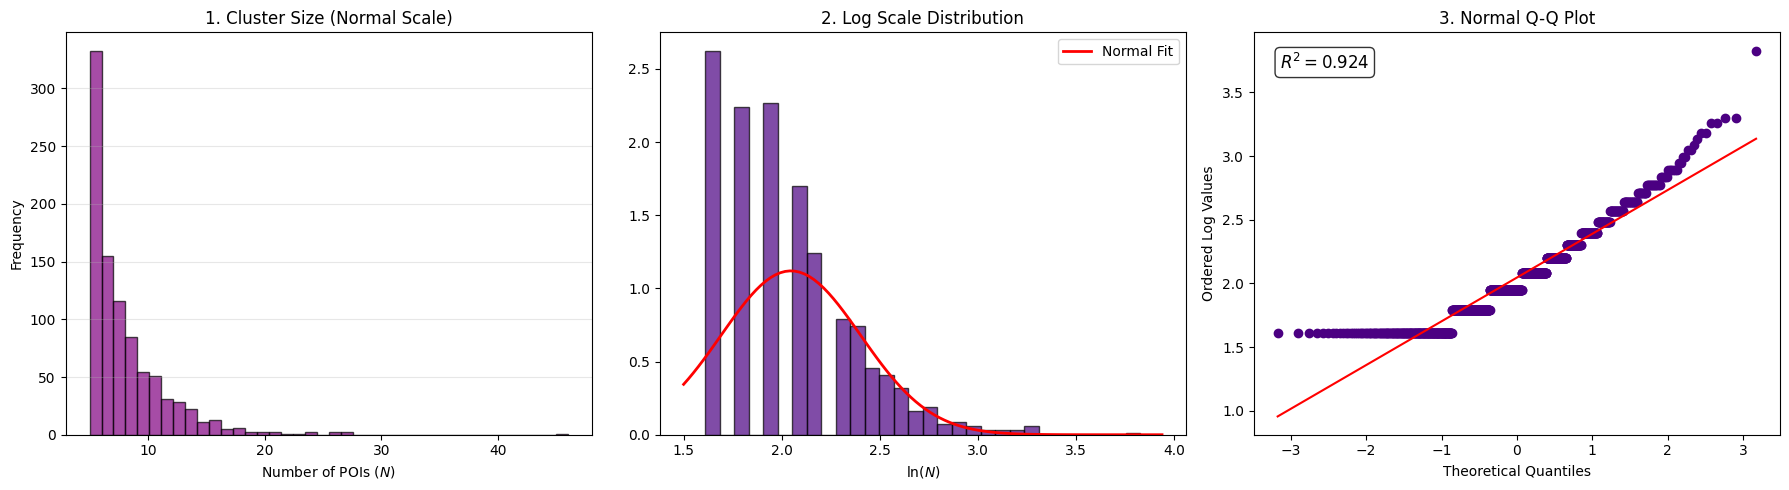

In [201]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. Prepare Data
cluster_counts = poi_df[poi_df['cluster'] != -1]['cluster'].value_counts().values
log_counts = np.log(cluster_counts)

# 2. Fit Normal Distribution and calculate R-squared
mu, std = stats.norm.fit(log_counts)
(osm, osr), (slope, intercept, r) = stats.probplot(log_counts, dist="norm")
r_squared = r**2

# 3. Create 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Subplot 1: Normal Histogram (The Raw Skew) ---
axes[0].hist(cluster_counts, bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title("1. Cluster Size (Normal Scale)")
axes[0].set_xlabel("Number of POIs ($N$)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3)

# --- Subplot 2: Log Histogram (The Bell Curve Check) ---
axes[1].hist(log_counts, bins=30, color='indigo', edgecolor='black', alpha=0.7, density=True)
xmin, xmax = axes[1].get_xlim()
x_range = np.linspace(xmin, xmax, 100)
pdf_curve = stats.norm.pdf(x_range, mu, std)
axes[1].plot(x_range, pdf_curve, 'r', linewidth=2, label='Normal Fit')
axes[1].set_title("2. Log Scale Distribution")
axes[1].set_xlabel(r"$\ln(N)$")
axes[1].legend()

# --- Subplot 3: Q-Q Plot (The Goodness of Fit) ---
stats.probplot(log_counts, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('indigo')
axes[2].get_lines()[0].set_markeredgecolor('indigo')
axes[2].get_lines()[1].set_color('red')
axes[2].set_title("3. Normal Q-Q Plot")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Ordered Log Values")

# Add R-squared text box
axes[2].text(0.05, 0.95, fr"$R^2 = {r_squared:.3f}$", transform=axes[2].transAxes, 
             fontsize=12, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Funnily enough, that's a great R^2 value! It seems like the number of POIs behave log-normally!

Our Q-Q plot is even more impressive - the middle section is almost a straight line! This means that my 'typical' neighborhood clusters are perfectly following the expected density. 
We have 'heavy tails' on both sides - that means unexpectedly high density on both 'small hubs' and 'super-hubs'. 
- The small hubs make sense - it's a result of our OPTICS clustering having a strict minimum # of POIs to be considered for a cluster. So while the distribution "expects" clusters with 1, 2, 3 or 4 POIs, we only let clusters with 5 and above exist.
- The right tail, on the other hand, means that the biggest hubs in our data are even more densely populated than expected!

##### Under-Representation of Malls

I looked around manually at some malls that I visit regularly, and I noticed malls aren't represented very well in our data.

More specifically - malls are the only POI in our data that actually represents more POIs inside of them! However, the individual shops inside malls aren't tagged very consistently in the data, so malls become under-scored.

Take a look at some specific examples of malls around my area:

In [202]:
# --- 7. Snapshot: Mall Investigation (Fixed for AttributeError) ---
investigation_sites = [
    ["Big Yehud (Rank 7)", 32.0260, 34.9003], 
    ["Savyonim Mall (Noise)", 32.0304, 34.8783], 
    ["Kiryat Ono Mall (Rank 7)", 32.0556, 34.8634]
]

invest_fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[site[0] for site in investigation_sites],
    # We use 'map' type for the new Scattermap traces
    specs=[[{"type": "map"}, {"type": "map"}, {"type": "map"}]]
)

for i, (name, lat, lon) in enumerate(investigation_sites, 1):
    # Filter points within a 500m radius
    mask = (np.sqrt((poi_df.geometry.y - lat)**2 + (poi_df.geometry.x - lon)**2) < 0.005)
    df_zoom = poi_df[mask]

    invest_fig.add_trace(
        go.Scattermap(
            lat=df_zoom.geometry.y,
            lon=df_zoom.geometry.x,
            mode='markers',
            marker=dict(
                size=12, 
                color=[color_map.get(r, "#5F5F5F") for r in df_zoom['Stability Rank']],
                opacity=0.8
            ),
            name=name,
            # We stack Cluster and POI_type into customdata
            customdata=np.stack((df_zoom['cluster'], df_zoom['POI_type']), axis=-1),
            # %{customdata[0]} pulls the Cluster, %{customdata[1]} pulls the Type
            hovertemplate=(
                "<b>Cluster: %{customdata[0]}</b><br>" +
                "Type: %{customdata[1]}<br>" +
                "Lat: %{lat:.4f}<br>" +
                "Lon: %{lon:.4f}" +
                "<extra></extra>"
            ),
            showlegend=False
        ),
        row=1, col=i
    )


# --- THE FIX FOR AttributeError ---
# We iterate through the layout and update the specific map domains
# If 'update_map' fails, this manual layout update is the foolproof backup.
for i in range(1, 4):
    map_key = f"map{i}" if i > 1 else "map"
    invest_fig.layout[map_key].update(
        style="carto-positron",
        center=dict(lat=investigation_sites[i-1][1], lon=investigation_sites[i-1][2]),
        zoom=16
    )

invest_fig.update_layout(
    height=500, 
    title_text="Site Investigation: High Suitability Malls Marked as Low Rank/Noise",
    margin={"r":10,"t":80,"l":10,"b":10}
)

invest_fig.show()

Let's take a look at how clusters with malls were ranked across all the data:

In [203]:
# Filter for just malls
malls_only = poi_df[poi_df["POI_type"] == 'mall']

# Count the occurrences of each rank
mall_rank_counts = malls_only['Stability Rank'].value_counts().sort_index()

# Plot the distribution
mall_hist = px.bar(
    mall_rank_counts, 
    labels={'value': 'Number of Points', 'index': 'Stability Rank'},
    title="Current Rank Distribution for 'Mall' POIs",
    color=mall_rank_counts.index,
    color_discrete_map=color_map
)
mall_hist.show()

print(f"Total Mall Points: {len(malls_only)}")
print(mall_rank_counts)

Total Mall Points: 406
Stability Rank
Noise     237
Rank 1      1
Rank 2      8
Rank 3      2
Rank 4      1
Rank 5      6
Rank 6      2
Rank 7    149
Name: count, dtype: int64


Quite obviously - almost ALL malls have been categorizes as noise or rank 7. This indicates a problem with out data - the individual shops inside malls just haven't been tagged properly in OSM data.

To fix this, I will:
- promote any cluster that contains a mall to Rank 1
- promote 'noise' points that are actually malls to Rank 1, with a small buffer around them.

Note: at this point I thought about going back and not using centroids for malls, and using their actual polygon to include POIs within them. The problem is that some malls in OSM are categorized as a 'point' and some are polygons. Because of this incosistency, I decided to stick with centroids.

In [204]:
# Let's start by getting all cluster IDs that contain a mall (that aren't '-1', noise)
c_ids = malls_only.loc[malls_only['cluster'] != -1, 'cluster'].unique()

# if not 'noise' and is in a cluster with a mall, become rank 1
poi_df.loc[poi_df['cluster'].isin(c_ids), 'Stability Rank'] = 'Rank 1'

# if 'noise' and is a mall, become rank 1 and also add all 'noise' POIs to it as a cluster in a 100m radius
noise_malls = malls_only[malls_only['cluster'] == -1]

# Extract lat (y) and lon (x) from the GeoSeries
noise_points_df = poi_df[poi_df['Stability Rank'] == 'Noise']
noise_lat = noise_points_df.geometry.y.values
noise_lon = noise_points_df.geometry.x.values
mall_lat = noise_malls.geometry.y.values
mall_lon = noise_malls.geometry.x.values

# Stack them into (N, 2) arrays and convert to radians
noise_coords = np.radians(np.stack([noise_lat, noise_lon], axis=-1))
mall_coords = np.radians(np.stack([mall_lat, mall_lon], axis=-1))

tree = BallTree(noise_coords, metric='haversine')
radius = 0.1 / 6371.0 # 100m
indices = tree.query_radius(mall_coords, r=radius) # go over every 'noise' mall and check for other 'noise's in a 100m radius

# now let's promote them!
for idx_list in indices:
    target_indices = noise_points_df.index[idx_list]
    poi_df.loc[target_indices, 'Stability Rank'] = 'Rank 1'
    poi_df.loc[target_indices, 'cluster'] = int(poi_df['cluster'].max()) + 1

# Let's check the results now
print(poi_df.loc[poi_df['POI_type'] == 'mall', 'Stability Rank'].value_counts()) # Great! All malls are rank 1 now.


Stability Rank
Rank 1    406
Name: count, dtype: int64


In [205]:
# --- 7. Snapshot: Mall Investigation (Fixed for AttributeError) ---
investigation_sites = [
    ["Big Yehud (Rank 1)", 32.0260, 34.9003], 
    ["Savyonim Mall (Rank 1)", 32.0304, 34.8783], 
    ["Kiryat Ono Mall (Rank 1)", 32.0556, 34.8634]
]

invest_fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[site[0] for site in investigation_sites],
    # We use 'map' type for the new Scattermap traces
    specs=[[{"type": "map"}, {"type": "map"}, {"type": "map"}]]
)

for i, (name, lat, lon) in enumerate(investigation_sites, 1):
    # Filter points within a 500m radius
    mask = (np.sqrt((poi_df.geometry.y - lat)**2 + (poi_df.geometry.x - lon)**2) < 0.005)
    df_zoom = poi_df[mask]

    invest_fig.add_trace(
        go.Scattermap(
            lat=df_zoom.geometry.y,
            lon=df_zoom.geometry.x,
            mode='markers',
            marker=dict(
                size=12, 
                color=[color_map.get(r, "#5F5F5F") for r in df_zoom['Stability Rank']],
                opacity=0.8
            ),
            name=name,
            # We stack Cluster and POI_type into customdata
            customdata=np.stack((df_zoom['cluster'], df_zoom['POI_type']), axis=-1),
            # %{customdata[0]} pulls the Cluster, %{customdata[1]} pulls the Type
            hovertemplate=(
                "<b>Cluster: %{customdata[0]}</b><br>" +
                "Type: %{customdata[1]}<br>" +
                "Lat: %{lat:.4f}<br>" +
                "Lon: %{lon:.4f}" +
                "<extra></extra>"
            ),
            showlegend=False
        ),
        row=1, col=i
    )

# --- THE FIX FOR AttributeError ---
# We iterate through the layout and update the specific map domains
# If 'update_map' fails, this manual layout update is the foolproof backup.
for i in range(1, 4):
    map_key = f"map{i}" if i > 1 else "map"
    invest_fig.layout[map_key].update(
        style="carto-positron",
        center=dict(lat=investigation_sites[i-1][1], lon=investigation_sites[i-1][2]),
        zoom=16
    )

invest_fig.update_layout(
    height=500, 
    title_text="Malls Previously Marked as Noise/Rank 7, Now Properly Clustered and Marked as Rank 1",
    margin={"r":10,"t":80,"l":10,"b":10}
)

invest_fig.show()

Let's look at our updated POI cluster map now:

In [206]:
# --- 1. RE-SORT & SYNC (Crucial after manual Rank updates) ---
# Ensure legend order is consistent
num_actual_bins = 12 # Matching your qcut logic
legend_order = ["Noise"] + [f"Rank {i}" for i in range(num_actual_bins, 0, -1)]

# Re-apply sort order so Rank 1 is plotted LAST (on top)
rank_sorting = {f"Rank {i}": (num_actual_bins - i + 1) for i in range(1, num_actual_bins + 1)}
rank_sorting["Noise"] = 0
poi_df['sort_order'] = poi_df['Stability Rank'].map(rank_sorting).fillna(0)
poi_df = poi_df.sort_values('sort_order', ascending=True)

# --- 2. Plot Map ---
map_fig = go.Figure()

for label in legend_order:
    df_sub = poi_df[poi_df['Stability Rank'] == label]
    if df_sub.empty:
        continue
    
    map_fig.add_trace(go.Scattermap(
        lat=df_sub.geometry.y,
        lon=df_sub.geometry.x,
        mode='markers',
        marker=dict(
            size=7 if label != "Noise" else 4, 
            color=color_map.get(label, "#5F5F5F"),
            opacity=0.9 if label != "Noise" else 0.5
        ),
        name=label,
        # Hover data including the now-corrected Cluster IDs
        customdata=np.stack((df_sub['cluster'], df_sub['POI_type']), axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Cluster ID: %{customdata[0]}<br>" +
            "Type: %{customdata[1]}<br>" +
            "Lat: %{lat:.4f}<br>Lon: %{lon:.4f}<extra></extra>"
        ),
        text=df_sub['Stability Rank']
    ))

# Standard Israel view logic
center_lat = poi_df.geometry.y.mean()
center_lon = poi_df.geometry.x.mean()

map_fig.update_layout(
    map=dict(
        style="carto-positron", 
        center=dict(lat=center_lat, lon=center_lon),
        zoom=8.5 
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    title="Major Activity Hubs in Israel, Ranked by POI Density",
    height=700, 
    legend=dict(
        traceorder="reversed",
        bgcolor="rgba(255,255,255,0.7)",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

map_fig.show()

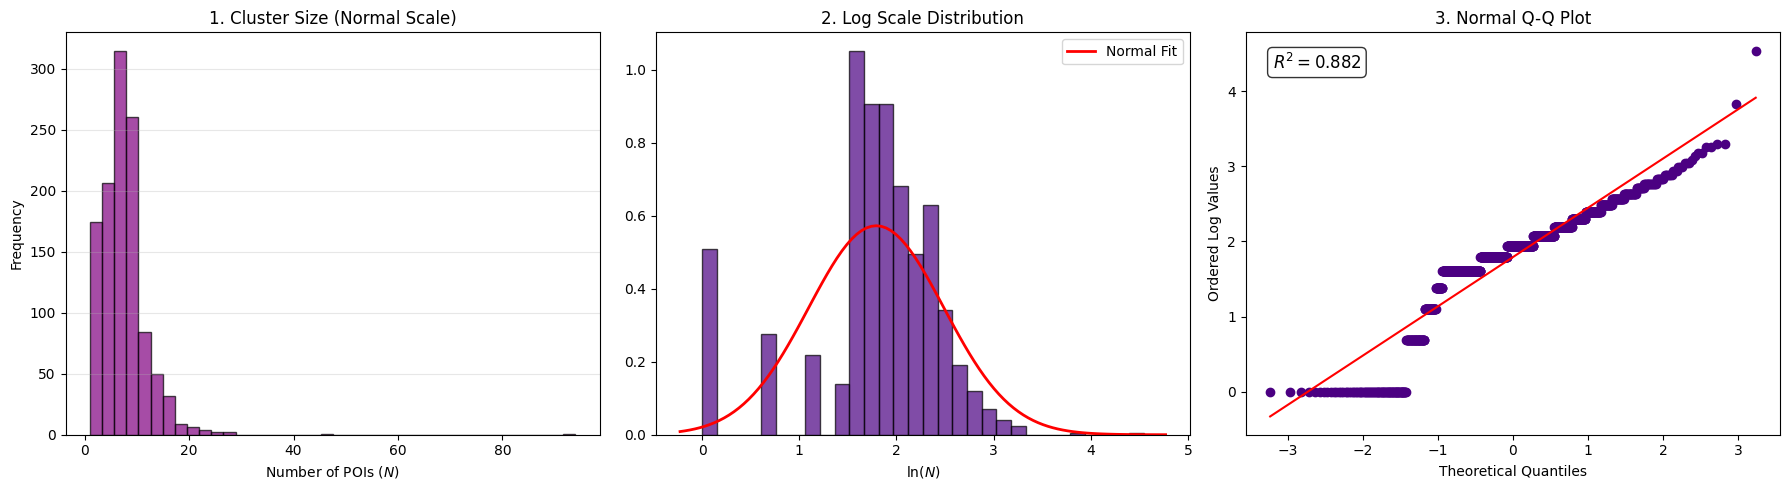

In [207]:
# 1. Prepare Data
cluster_counts = poi_df[poi_df['cluster'] != -1]['cluster'].value_counts().values
log_counts = np.log(cluster_counts)

# 2. Fit Normal Distribution and calculate R-squared
mu, std = stats.norm.fit(log_counts)
(osm, osr), (slope, intercept, r) = stats.probplot(log_counts, dist="norm")
r_squared = r**2

# 3. Create 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Subplot 1: Normal Histogram (The Raw Skew) ---
axes[0].hist(cluster_counts, bins=40, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_title("1. Cluster Size (Normal Scale)")
axes[0].set_xlabel("Number of POIs ($N$)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3)

# --- Subplot 2: Log Histogram (The Bell Curve Check) ---
axes[1].hist(log_counts, bins=30, color='indigo', edgecolor='black', alpha=0.7, density=True)
xmin, xmax = axes[1].get_xlim()
x_range = np.linspace(xmin, xmax, 100)
pdf_curve = stats.norm.pdf(x_range, mu, std)
axes[1].plot(x_range, pdf_curve, 'r', linewidth=2, label='Normal Fit')
axes[1].set_title("2. Log Scale Distribution")
axes[1].set_xlabel(r"$\ln(N)$")
axes[1].legend()

# --- Subplot 3: Q-Q Plot (The Goodness of Fit) ---
stats.probplot(log_counts, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('indigo')
axes[2].get_lines()[0].set_markeredgecolor('indigo')
axes[2].get_lines()[1].set_color('red')
axes[2].set_title("3. Normal Q-Q Plot")
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Ordered Log Values")

# Add R-squared text box
axes[2].text(0.05, 0.95, fr"$R^2 = {r_squared:.3f}$", transform=axes[2].transAxes, 
             fontsize=12, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Manually adding hubs (of malls) with 0~5 POIs has decreased our R^2. Makes sense! We're adding extreme data to the tails of the distribution.

In [225]:
# Before moving on, I'll take the opportunity to clean up poi_df
# poi_df.drop(columns='temp_score', inplace=True)
poi_df[poi_df['cluster'] != -1]

,geometry,POI_type,cluster,Stability Rank,sort_order
21483,POINT (35.30228 32.70607),fast_food,647,Rank 7,6
28443,POINT (34.76896 32.07231),restaurant,230,Rank 7,6
21416,POINT (34.91801 32.43705),bank,406,Rank 7,6
28476,POINT (34.96079 32.7837),Other,808,Rank 7,6
28475,POINT (34.85986 32.33017),seafood,533,Rank 7,6
...,...,...,...,...,...
24591,POINT (34.88615 32.08591),convenience,368,Rank 1,12
310,POINT (34.86194 32.06105),mall,932,Rank 1,12
6,POINT (34.93367 32.5692),mall,931,Rank 1,12
95,POINT (34.79509 31.2437),mall,930,Rank 1,12


### Part 2: Adding Additional Layers